In [21]:
from tkinter import Grid
from typing import Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report, balanced_accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Normalizer, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [35]:


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


MAX_SAMPLES_DATA = 100000


def reduce_dataset(df: pd.DataFrame, classification=True) -> pd.DataFrame:
    new_df = df.copy()

    new_df = new_df[new_df["CANCELLED"] == 0]

    if MAX_SAMPLES_DATA > 0:
        new_df = new_df.sample(n=MAX_SAMPLES_DATA, random_state=42)

    # Add new Rows
    delay_cols = [
        "DEPARTURE_DELAY",
        "ARRIVAL_DELAY",
        "SECURITY_DELAY",
        "AIRLINE_DELAY",
        "LATE_AIRCRAFT_DELAY",
        "WEATHER_DELAY",
        "AIR_SYSTEM_DELAY",
    ]

    delays = new_df[delay_cols].fillna(0)


    # Ich möchte wissen ob ich meinen Anschluss Flug schaffe ohne zeitlichen Druck
    if classification:
        new_df["DELAY"] = (
            delays["ARRIVAL_DELAY"] > 15
        )
    else:
        new_df["DELAY"] = delays["ARRIVAL_DELAY"]
    # Remove not needed Rows
    new_df.drop(columns=["YEAR"], inplace=True)
   # new_df.drop(columns=["SCHEDULED_DEPARTURE"], inplace=True)
    new_df.drop(columns=["DEPARTURE_TIME"], inplace=True)
    new_df.drop(columns=["DEPARTURE_DELAY"], inplace=True)
    new_df.drop(columns=["TAXI_OUT"], inplace=True)
    new_df.drop(columns=["TAXI_IN"], inplace=True)
    new_df.drop(columns=["WHEELS_OFF"], inplace=True)
    new_df.drop(columns=["WHEELS_ON"], inplace=True)
    new_df.drop(columns=["ELAPSED_TIME"], inplace=True)
   # new_df.drop(columns=["AIR_TIME"], inplace=True)
    new_df.drop(columns=["ARRIVAL_TIME"], inplace=True)
    new_df.drop(columns=["AIRLINE_DELAY"], inplace=True)
    new_df.drop(columns=["LATE_AIRCRAFT_DELAY"], inplace=True)
    new_df.drop(columns=["DIVERTED"], inplace=True)
    new_df.drop(columns=["CANCELLED"], inplace=True)
    new_df.drop(columns=["CANCELLATION_REASON"], inplace=True)
    new_df.drop(columns=["ARRIVAL_DELAY"], inplace=True)
    new_df.drop(columns=["SECURITY_DELAY"], inplace=True)
    new_df.drop(columns=["WEATHER_DELAY"], inplace=True)
    new_df.drop(columns=["AIR_SYSTEM_DELAY"], inplace=True)
    #new_df.drop(columns=["SCHEDULED_ARRIVAL"], inplace=True)
   # new_df.drop(columns=["DISTANCE"], inplace=True)
   # new_df.drop(columns=["SCHEDULED_TIME"], inplace=True)
    new_df.drop(columns=["TAIL_NUMBER"], inplace=True)
    new_df.drop(columns=["MONTH"], inplace=True)
    new_df.drop(columns=["DAY"], inplace=True)

    return new_df


def describe_dataset(dataset: pd.DataFrame, path: str):
    print(f"DESCRIBE========={path}")
    print(dataset.describe())
    print("HEAD=========")
    print(dataset.head())
    print("TAIL=========")
    print(dataset.tail())
    print("==============")

def load_dataset(path: str, classification=True) -> pd.DataFrame:
    dataset = pd.read_csv(path, low_memory=False)
    dataset = reduce_dataset(dataset, classification)
    describe_dataset(dataset, path)
    return dataset


ds_flights_classification = load_dataset("./data/flights.csv")
ds_flights_regression = load_dataset("./data/flights.csv", False)

DESCRIBE=========./data/flights.csv
       DAY_OF_WEEK  FLIGHT_NUMBER  SCHEDULED_DEPARTURE  SCHEDULED_TIME  \
count    100000.00      100000.00            100000.00       100000.00   
mean          3.94        2173.72              1329.31          141.67   
std           1.98        1758.13               482.97           75.11   
min           1.00           1.00                 1.00           20.00   
25%           2.00         728.00               919.00           85.00   
50%           4.00        1696.00              1325.00          123.00   
75%           6.00        3226.00              1730.00          173.00   
max           7.00        7438.00              2359.00          718.00   

       AIR_TIME  DISTANCE  SCHEDULED_ARRIVAL  
count  99740.00 100000.00          100000.00  
mean     113.26    823.10            1492.32  
std       71.98    606.99             506.82  
min       10.00     31.00               1.00  
25%       60.00    373.00            1110.00  
50%       94.00

### Display the Data in a pairplot to understand it

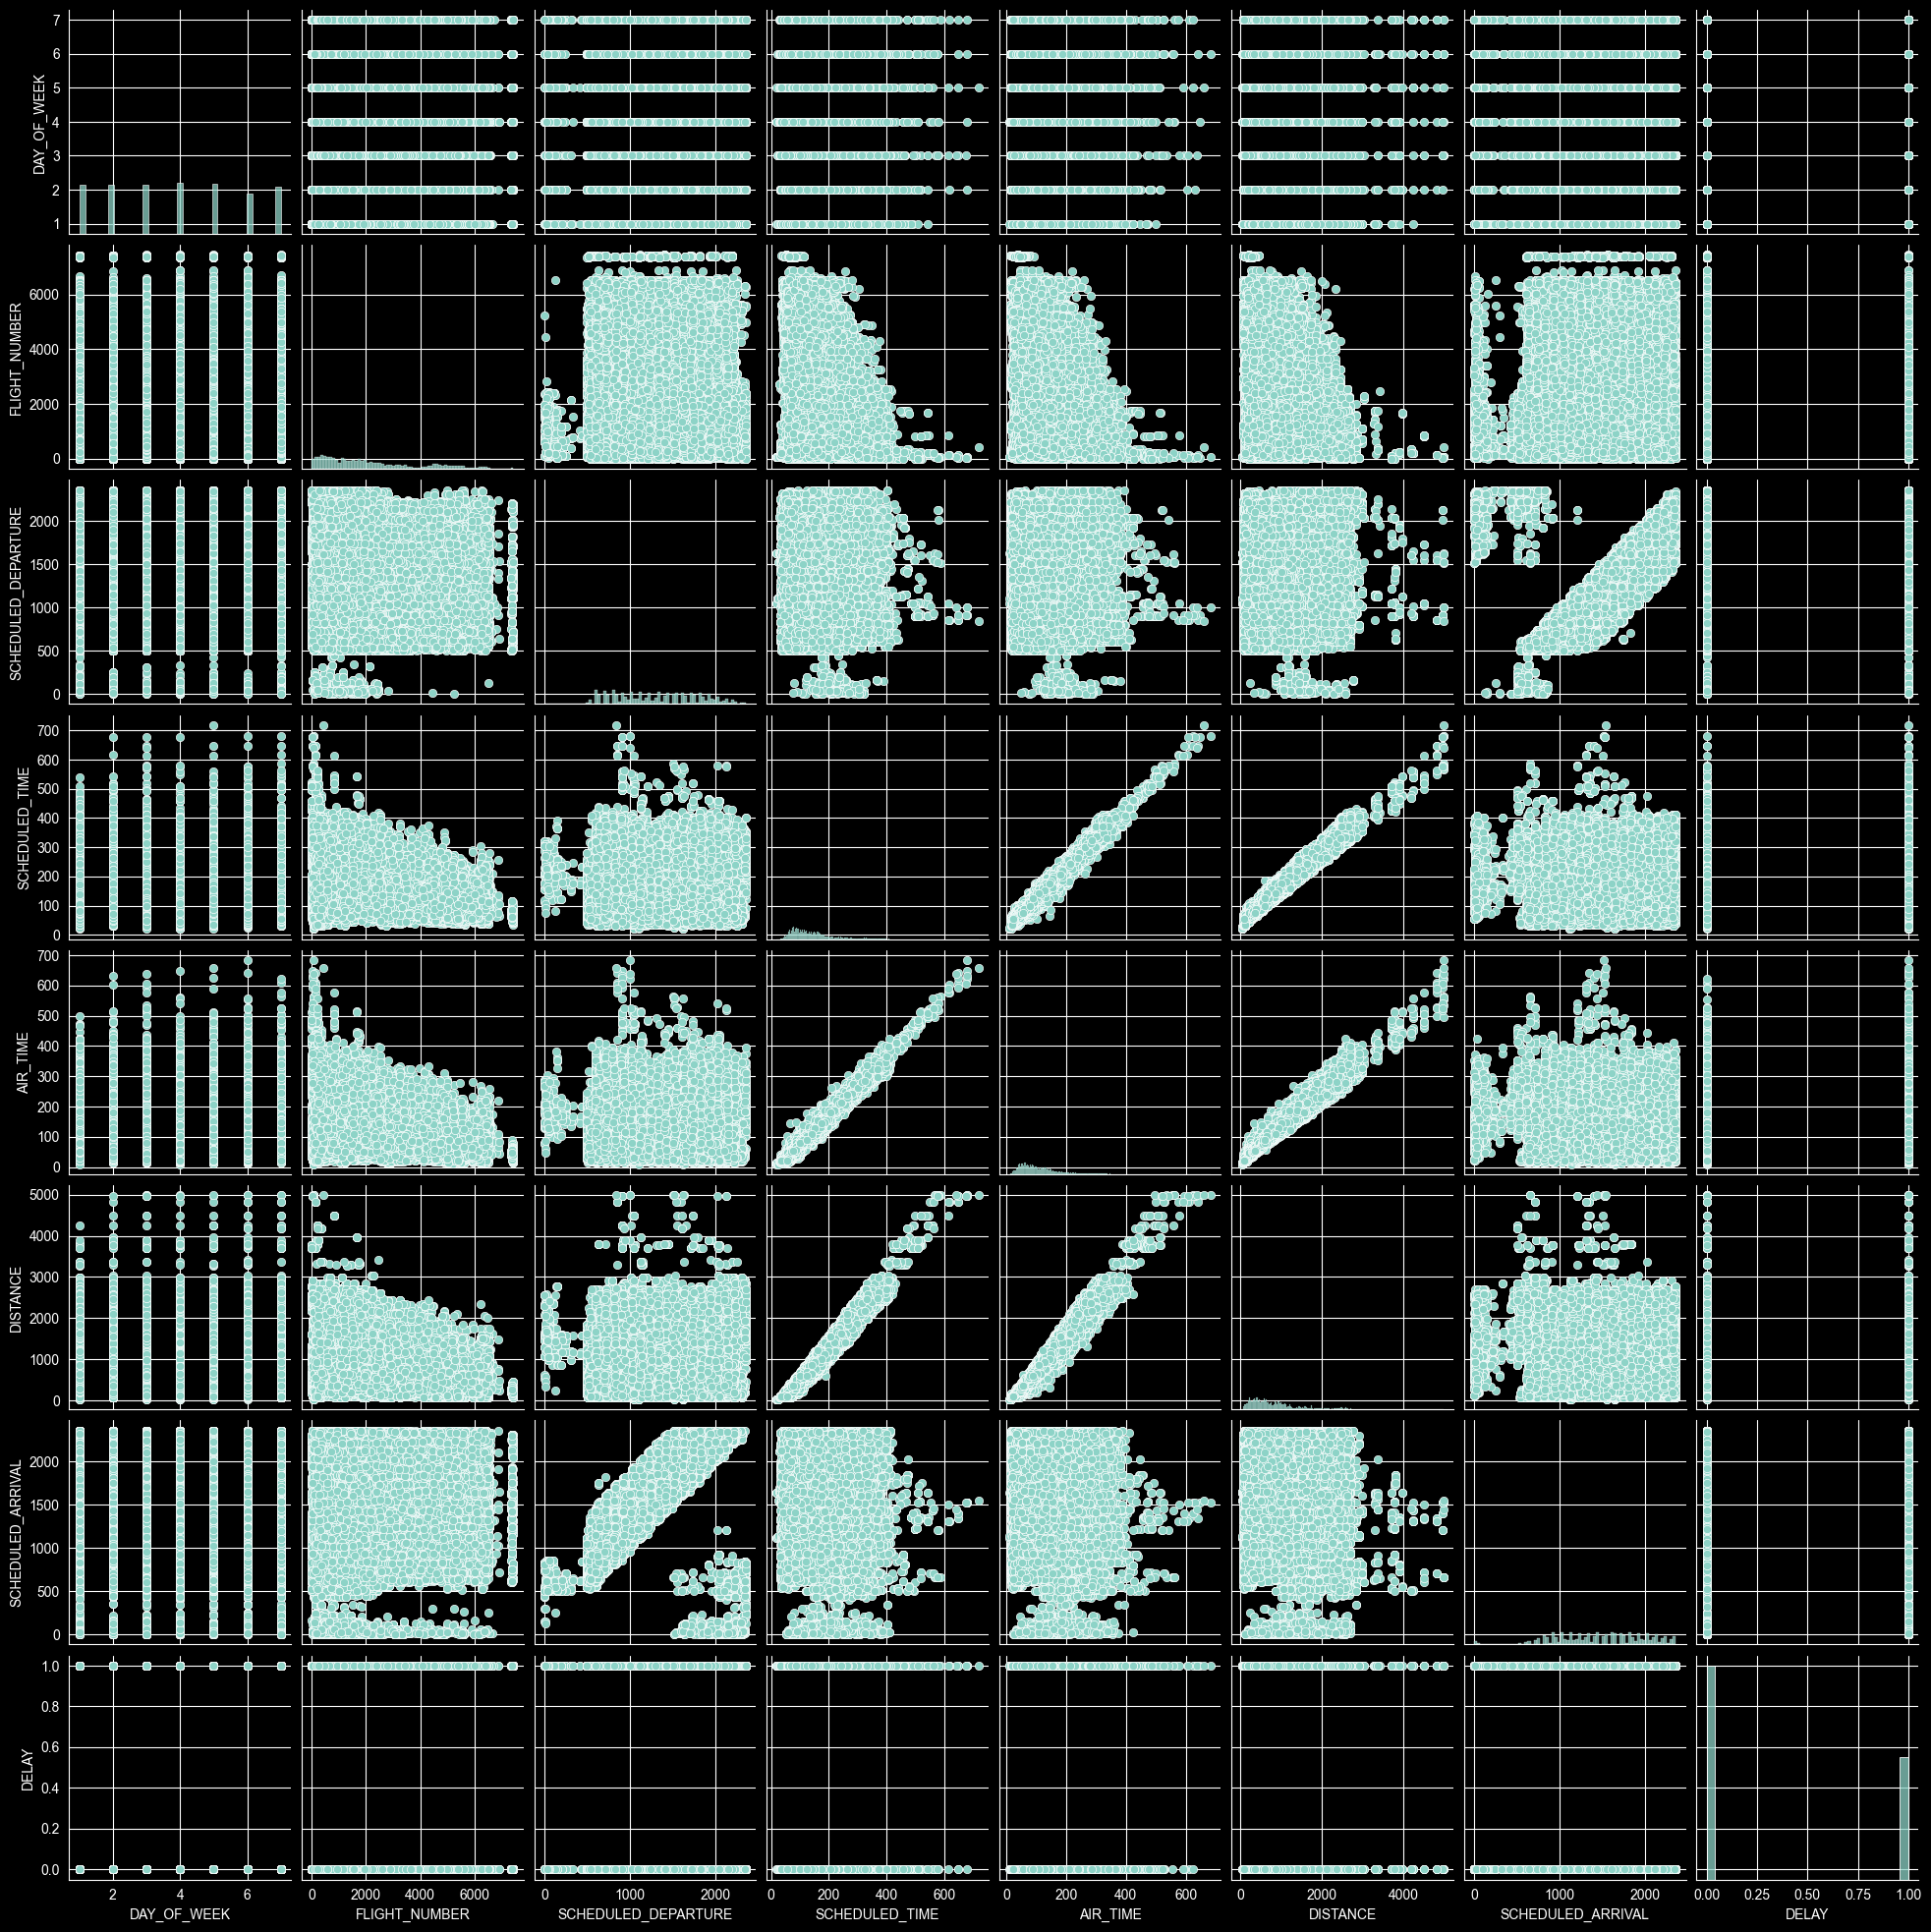

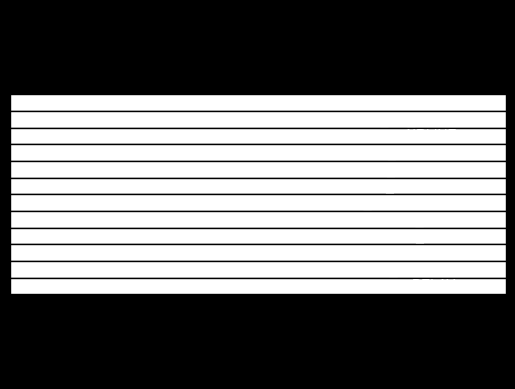

In [3]:
def plot_dataset(dataset: pd.DataFrame) -> None:
    new_df = dataset.copy()

    sns.pairplot(new_df)
    plt.show()

    plt.table(
        cellText=[[col] for col in dataset.columns],
        colLabels=["Columns"],
        loc="center"
    )
    plt.axis("off")
    plt.show()


plot_dataset(ds_flights_classification)

### Train / Test / Split

In [4]:
def tts(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    Y = df['DELAY']
    X = df.drop(columns=["DELAY"])

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = tts(ds_flights_classification)


X_train_reg, X_test_reg, y_train_reg, y_test_reg = tts(ds_flights_regression)

### Create Transformer to transform text to numeric Data

In [36]:
def transform_text_data() -> ColumnTransformer:
    categorical_cols = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
    numeric_cols = [
        "DAY_OF_WEEK",
        #"SCHEDULED_DEPARTURE",
        #"SCHEDULED_ARRIVAL",
        "SCHEDULED_TIME",
        "DISTANCE",
        "FLIGHT_NUMBER",
       # "AIR_TIME"
    ]

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])

    transformer = ColumnTransformer(transformers=[
        ("cat", categorical_transformer, categorical_cols),
    ])

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    return ColumnTransformer(transformers=[
        ("cat", transformer, categorical_cols),
        ("num", numeric_transformer, numeric_cols),
    ])

### 1 Train the modell Decision Tree -> Found Accuracy 0.64

In [6]:

def train_decision_tree(X_train, y_train, X_test, y_test):
    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
        ("normalizer", Normalizer())
    ])

    model = Pipeline(steps=[
        ('preprocess', preprocess),
        ('regression', DecisionTreeClassifier())
    ])


    param_grid = {
        "regression__criterion": ["gini", "entropy", "log_loss"],
        "regression__max_depth": [None, 2, 3, 5, 10, 15, 20, 30, 50],
        "regression__min_samples_split": [2,  50],
        "regression__min_samples_leaf": [1, 20],
    }
    gs = GridSearchCV(model, param_grid, cv=2)
    gs.fit(X_train, y_train)
    #model.fit(X_train, y_train)

    print(gs.best_score_)
    return gs.best_estimator_

best_decision_tree = train_decision_tree(X_train, y_train, X_test, y_test)
print(best_decision_tree)

0.6358125
Pipeline(steps=[('preprocess',
                 Pipeline(steps=[('transform',
                                  ColumnTransformer(transformers=[('cat',
                                                                   Pipeline(steps=[('imputer',
                                                                                    SimpleImputer(strategy='most_frequent')),
                                                                                   ('encoder',
                                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                                   ['AIRLINE',
                                                                    'ORIGIN_AIRPORT',
                                                                    'DESTINATION_AIRPORT']),
                                                                  ('num',
                                                               

### 2 Train the Modell - LogisitcRegression

In [7]:
def train_logistic_regression(X_train, y_train, X_test, y_test):

    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
        ("normalizer", Normalizer())
    ])

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("regression", LogisticRegression(max_iter=1000))
    ])

    param_grid = {
        "regression__C": [0.01, 0.1, 1, 10, 100],
    }

    gs = GridSearchCV(model, param_grid, cv=2)
    gs.fit(X_train, y_train)

    print("Best CV Score:", gs.best_score_)
    print("Best Params:", gs.best_params_)

    y_train_pred = gs.predict(X_train)
    y_test_pred = gs.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    print("Train MAE:", train_mae)
    print("Test MAE:", test_mae)

    plt.figure(figsize=(6, 4))
    plt.bar(["Train MAE", "Test MAE"], [train_mae, test_mae])
    plt.ylabel("Mean Absolute Error")
    plt.title("Logistic Regression MAE")
    plt.show()

#train_logistic_regression(X_train_reg, y_train_reg, X_test_reg, y_test_reg)

### Boosting with Decission Tree

In [8]:
def train_with_boosting(X_train, y_train, X_test, y_test):
    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
        ("normalizer", Normalizer())
    ])

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("classifier", AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=10, min_samples_leaf=20),
            random_state=42
        ))
    ])

    param_grid = {
        "classifier__n_estimators": [50, 100, 200],
        "classifier__learning_rate": [0.01, 0.1, 0.5, 1.0],
        "classifier__estimator__max_depth": [1, 2, 3],
        "classifier__estimator__min_samples_leaf": [1, 5, 10],
    }

    gs = GridSearchCV(
        model,
        param_grid,
        cv=2,
        scoring="accuracy",
        n_jobs=-1
    )

    gs.fit(X_train, y_train)

    print("Best CV score:", gs.best_score_)
    print("Best params:", gs.best_params_)

    y_pred = gs.predict(X_test)
    print("Test accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))

#train_with_boosting(X_train, y_train, X_test, y_test)

KeyboardInterrupt: 

### Boosting with multiple Clasifier

In [19]:
def train_with_boosting_knn(X_train, y_train, X_test, y_test):
    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
        ("normalizer", Normalizer())
    ])

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("classifier", AdaBoostClassifier(random_state=42))
    ])

    param_grid = {
        "classifier__estimator": [KNeighborsClassifier(), DecisionTreeClassifier(), RandomForestClassifier(), GaussianProcessClassifier()],
    }

    gs = GridSearchCV(
        model,
        param_grid,
        cv=2,
        scoring="accuracy",
        n_jobs=-1
    )

    gs.fit(X_train, y_train)



    print("Best CV score:", gs.best_score_)
    print("Best params:", gs.best_params_)

    y_pred = gs.predict(X_test)
    print("Test accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))

#train_with_boosting_knn(X_train, y_train, X_test, y_test)

### Boosting

In [38]:
def train_with_boosting_dectree(X_train, y_train, X_test, y_test):

    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
    ])

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("classifier", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )),
    ])

    param_grid = {
        "classifier__n_estimators": [100, 300, 500],
        "classifier__max_depth": [2, 3, 4, 5],
        "classifier__learning_rate": [0.01, 0.05, 0.1],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0],
        "classifier__min_child_weight": [1, 5, 10],
        "classifier__gamma": [0, 1, 5],
    }

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    gs = GridSearchCV(
        model,
        param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    )

    gs.fit(X_train, y_train.astype(int))

    transformer = (
        gs.best_estimator_
        .named_steps["preprocess"]
        .named_steps["transform"]
    )

    feature_names = transformer.get_feature_names_out()

    print("Features nach dem Transform:")
    print("Anzahl:", len(feature_names))
    print(feature_names[:100])

    print("Best CV score:", gs.best_score_)
    print("Best params:", gs.best_params_)

    y_pred = gs.predict(X_test)

    print(classification_report(y_test.astype(int), y_pred, zero_division=0))


train_with_boosting_dectree(X_train, y_train, X_test, y_test)

Features nach dem Transform:
Anzahl: 1175
['cat__cat__AIRLINE_AA' 'cat__cat__AIRLINE_AS' 'cat__cat__AIRLINE_B6'
 'cat__cat__AIRLINE_DL' 'cat__cat__AIRLINE_EV' 'cat__cat__AIRLINE_F9'
 'cat__cat__AIRLINE_HA' 'cat__cat__AIRLINE_MQ' 'cat__cat__AIRLINE_NK'
 'cat__cat__AIRLINE_OO' 'cat__cat__AIRLINE_UA' 'cat__cat__AIRLINE_US'
 'cat__cat__AIRLINE_VX' 'cat__cat__AIRLINE_WN'
 'cat__cat__ORIGIN_AIRPORT_10135' 'cat__cat__ORIGIN_AIRPORT_10136'
 'cat__cat__ORIGIN_AIRPORT_10140' 'cat__cat__ORIGIN_AIRPORT_10141'
 'cat__cat__ORIGIN_AIRPORT_10146' 'cat__cat__ORIGIN_AIRPORT_10155'
 'cat__cat__ORIGIN_AIRPORT_10157' 'cat__cat__ORIGIN_AIRPORT_10158'
 'cat__cat__ORIGIN_AIRPORT_10165' 'cat__cat__ORIGIN_AIRPORT_10208'
 'cat__cat__ORIGIN_AIRPORT_10257' 'cat__cat__ORIGIN_AIRPORT_10279'
 'cat__cat__ORIGIN_AIRPORT_10299' 'cat__cat__ORIGIN_AIRPORT_10333'
 'cat__cat__ORIGIN_AIRPORT_10372' 'cat__cat__ORIGIN_AIRPORT_10397'
 'cat__cat__ORIGIN_AIRPORT_10408' 'cat__cat__ORIGIN_AIRPORT_10423'
 'cat__cat__ORIGIN_AIRPORT_1

### Mean of Flugnummer

In [ ]:
def mode_or_first(x):
    mode = x.mode(dropna=True)
    if not mode.empty:
        return mode.iloc[0]
    return x.dropna().iloc[0] if not x.dropna().empty else np.nan


def group_by_flight_number_and_departure(X, y, target_strategy="majority"):
    df = X.copy()
    df["DELAY"] = y.to_numpy()

    group_cols = ["FLIGHT_NUMBER", "SCHEDULED_DEPARTURE", "DAY_OF_WEEK"]

    agg = {
        "AIRLINE": mode_or_first,
        "ORIGIN_AIRPORT": mode_or_first,
        "DESTINATION_AIRPORT": mode_or_first,
        "DAY_OF_WEEK": mode_or_first,
        "SCHEDULED_TIME": "mean",
        "DISTANCE": "mean",
        "DELAY": "mean",
    }

    grouped = df.groupby(group_cols, as_index=False).agg(agg)

    if target_strategy == "majority":
        grouped["DELAY"] = (grouped["DELAY"] >= 0.5).astype(int)
    elif target_strategy == "any_delay":
        grouped["DELAY"] = (grouped["DELAY"] > 0).astype(int)
    else:
        raise ValueError("target_strategy must be 'majority' or 'any_delay'")

    y_grouped = grouped["DELAY"]
    X_grouped = grouped.drop(columns=["DELAY"])

    return X_grouped, y_grouped

def train_with_boosting_with_mean(X_train, y_train, X_test, y_test):

    preprocess = Pipeline(steps=[
        ("transform", transform_text_data()),
    ])

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("classifier", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )),
    ])

    param_grid = {
        "classifier__n_estimators": [100, 300, 500],
        "classifier__max_depth": [2, 3, 4, 5],
        "classifier__learning_rate": [0.01, 0.05, 0.1],
        "classifier__subsample": [0.8, 1.0],
        "classifier__colsample_bytree": [0.8, 1.0],
        "classifier__min_child_weight": [1, 5, 10],
        "classifier__gamma": [0, 1, 5],
    }

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    gs = GridSearchCV(
        model,
        param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    )

    gs.fit(X_train, y_train.astype(int))

    transformer = (
        gs.best_estimator_
        .named_steps["preprocess"]
        .named_steps["transform"]
    )

    feature_names = transformer.get_feature_names_out()

    print("Features nach dem Transform:")
    print("Anzahl:", len(feature_names))
    print(feature_names[:100])

    print("Best CV score:", gs.best_score_)
    print("Best params:", gs.best_params_)

    y_pred = gs.predict(X_test)

    print(classification_report(y_test.astype(int), y_pred, zero_division=0))

X_train_mean, y_train_mean = group_by_flight_number_and_departure(
    X_train,
    y_train,
    target_strategy="majority"
)

X_test_mean, y_test_mean = group_by_flight_number_and_departure(
    X_test,
    y_test,
    target_strategy="majority"
)


train_with_boosting_with_mean(
    X_train_mean,
    y_train_mean,
    X_test_mean,
    y_test_mean
)



/Users/julianfink/Documents/Coding/CAS26/uni_project/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
